# Phase 2 — Exploratory Data Analysis
MIG Cement Demand Forecasting

Covers (per project brief Step 2):
- Demand patterns by site, cement type, and time period
- Seasonality and trends
- Correlation with weather variables
- Impact of planned pours on actual consumption
- Outlier / data quality detection

Reads from `data/processed/operations_clean.parquet` — the output of
`src/data/validate.py` (Phase 1). Re-run that script first if this file
is missing or stale.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

DATA_PATH = Path.cwd().parent / "data" / "processed" / "operations_clean.parquet"
df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df.head()

(32880, 17)


,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,region,behavior,overflow_tonnes,closing_inventory_raw_tonnes,stockout_risk,pour_shortfall_tonnes
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,North,aggressive,0.0,63.85,True,8.64
1,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,North,aggressive,0.0,38.56,False,0.00
2,2022-01-03,SITE_001,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,North,aggressive,0.0,47.06,False,0.00
3,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,North,aggressive,0.0,32.64,False,0.00
4,2022-01-05,SITE_001,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,North,aggressive,0.0,0.00,True,9.84


## 1. Overview

In [2]:
print("Date range:", df.date.min().date(), "to", df.date.max().date())
print("Sites:", df.site_id.nunique())
print("Cement types:", df.cement_type.unique())
print("Regions:", df.region.unique())
print("Behaviors:", df.behavior.unique())
df.groupby("behavior")["site_id"].nunique()

Date range: 2022-01-01 to 2024-12-31
Sites: 30
Cement types: <ArrowStringArray>
['CEM_II', 'CEM_I', 'CEM_III']
Length: 3, dtype: str
Regions: <ArrowStringArray>
['North', 'South', 'East', 'West']
Length: 4, dtype: str
Behaviors: <ArrowStringArray>
['aggressive', 'conservative', 'chaotic']
Length: 3, dtype: str


behavior
aggressive      14
chaotic          7
conservative     9
Name: site_id, dtype: int64

## 2. Demand patterns by site behavior

`behavior` (aggressive / conservative / chaotic) was identified in the
Phase 1 audit as the strongest structural signal in this dataset — it
directly encodes MIG's three real-world ordering failure modes. Start
here before slicing by region or cement type.

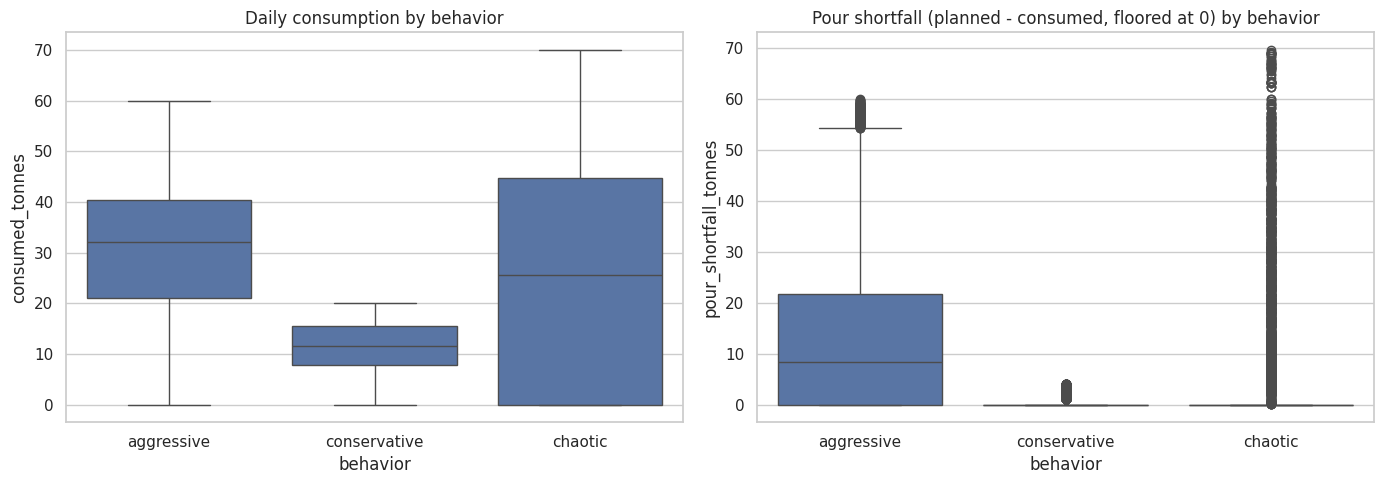

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="behavior", y="consumed_tonnes", ax=axes[0])
axes[0].set_title("Daily consumption by behavior")

sns.boxplot(data=df, x="behavior", y="pour_shortfall_tonnes", ax=axes[1])
axes[1].set_title("Pour shortfall (planned - consumed, floored at 0) by behavior")

plt.tight_layout()
plt.savefig("../data/processed/eda_01_behavior_boxplots.png", dpi=120)
plt.show()

In [4]:
behavior_summary = df.groupby("behavior").agg(
    avg_consumed=("consumed_tonnes", "mean"),
    avg_planned=("planned_pour_tonnes", "mean"),
    stockout_rate=("stockout_risk", "mean"),
    avg_overflow=("overflow_tonnes", "mean"),
    n_sites=("site_id", "nunique"),
).round(2)
behavior_summary

,avg_consumed,avg_planned,stockout_rate,avg_overflow,n_sites
behavior,,,,,
aggressive,30.01,42.74,0.65,0.00,14
chaotic,26.82,30.82,0.22,38.65,7
conservative,11.52,11.88,0.14,9762.27,9


## 3. Demand by cement type

In [5]:
type_summary = df.groupby("cement_type").agg(
    avg_consumed=("consumed_tonnes", "mean"),
    total_consumed=("consumed_tonnes", "sum"),
    avg_planned=("planned_pour_tonnes", "mean"),
).round(2)
type_summary

,avg_consumed,total_consumed,avg_planned
cement_type,,,
CEM_I,23.82,259954.71,30.96
CEM_II,23.74,263418.26,30.60
CEM_III,23.60,256556.24,30.53


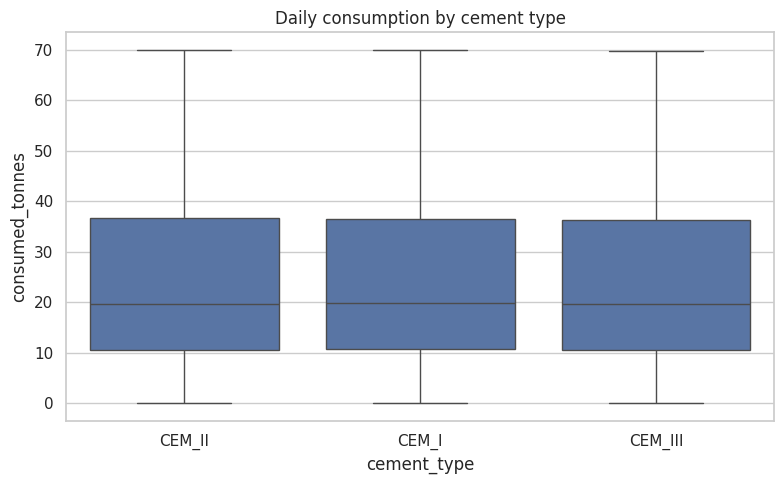

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="cement_type", y="consumed_tonnes", ax=ax)
ax.set_title("Daily consumption by cement type")
plt.tight_layout()
plt.savefig("../data/processed/eda_02_cement_type.png", dpi=120)
plt.show()

## 3b. Demand by region

Caveat from the Phase 1 audit: regions are unevenly sized (North=3 sites,
West=4, South=11, East=12). Treat North/West findings here as directional,
not statistically robust — small-sample regional splits are exactly where
it's easy to over-read noise as a pattern.

        avg_consumed  n_sites  stockout_rate
region                                      
East          24.252       12          0.381
North         17.595        3          0.309
South         24.460       11          0.434
West          24.685        4          0.409


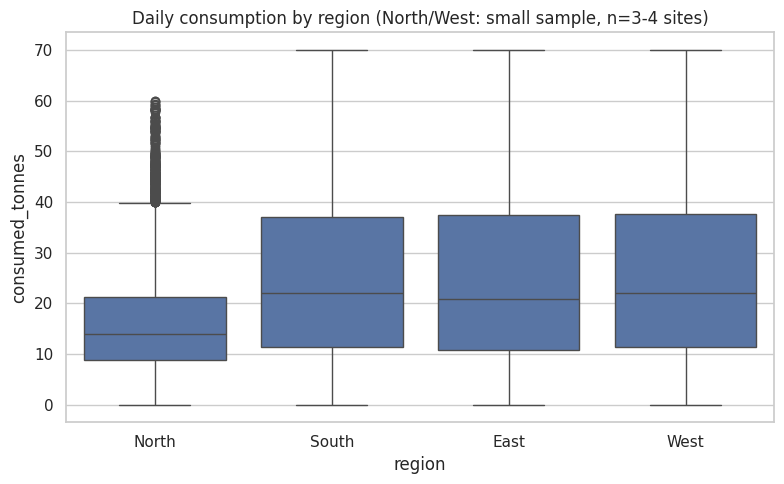

In [7]:
region_summary = df.groupby("region").agg(
    avg_consumed=("consumed_tonnes", "mean"),
    n_sites=("site_id", "nunique"),
    stockout_rate=("stockout_risk", "mean"),
).round(3)
print(region_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="region", y="consumed_tonnes", ax=ax)
ax.set_title("Daily consumption by region (North/West: small sample, n=3-4 sites)")
plt.tight_layout()
plt.savefig("../data/processed/eda_02b_region.png", dpi=120)
plt.show()

## 4. Time trends and seasonality

Aggregate to weekly (site-level daily demand is lumpy — zero on many
days, spikes on pour days) to see the underlying pattern more clearly.
This also mirrors the forecast granularity decision from Phase 0.

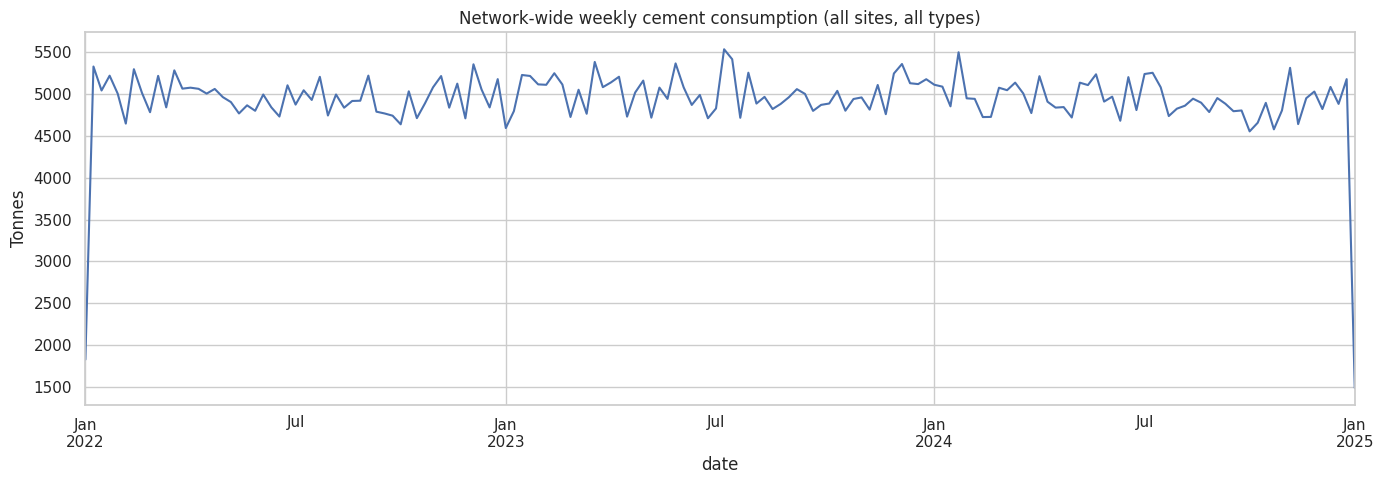

In [8]:
weekly = (
    df.set_index("date")
      .groupby("site_id")
      .resample("W")["consumed_tonnes"]
      .sum()
      .reset_index()
)

# Network-wide weekly total
network_weekly = weekly.groupby("date")["consumed_tonnes"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
network_weekly.plot(ax=ax)
ax.set_title("Network-wide weekly cement consumption (all sites, all types)")
ax.set_ylabel("Tonnes")
plt.tight_layout()
plt.savefig("../data/processed/eda_03_weekly_trend.png", dpi=120)
plt.show()

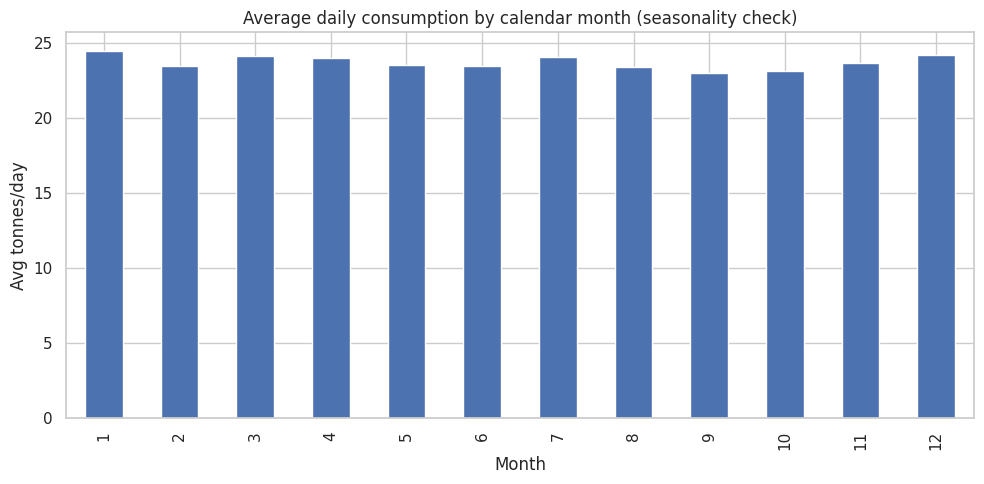

In [9]:
# Monthly seasonality — average consumption by calendar month, network-wide
monthly_seasonality = (
    df.assign(month=df.date.dt.month)
      .groupby("month")["consumed_tonnes"]
      .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))
monthly_seasonality.plot(kind="bar", ax=ax)
ax.set_title("Average daily consumption by calendar month (seasonality check)")
ax.set_xlabel("Month")
ax.set_ylabel("Avg tonnes/day")
plt.tight_layout()
plt.savefig("../data/processed/eda_04_monthly_seasonality.png", dpi=120)
plt.show()

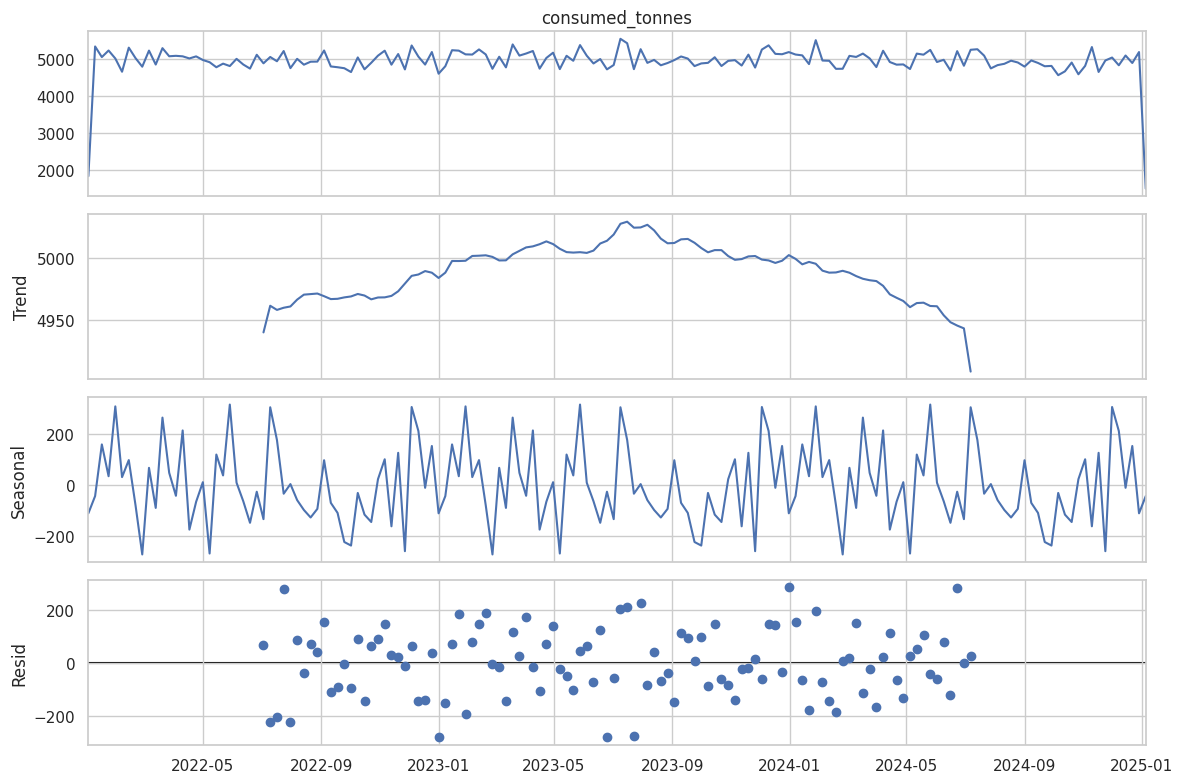

In [10]:
# Formal decomposition on network-wide weekly series (trend/seasonal/residual)
from statsmodels.tsa.seasonal import seasonal_decompose

ts = network_weekly.asfreq("W").interpolate()
decomp = seasonal_decompose(ts, model="additive", period=52)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig("../data/processed/eda_05_decomposition.png", dpi=120)
plt.show()

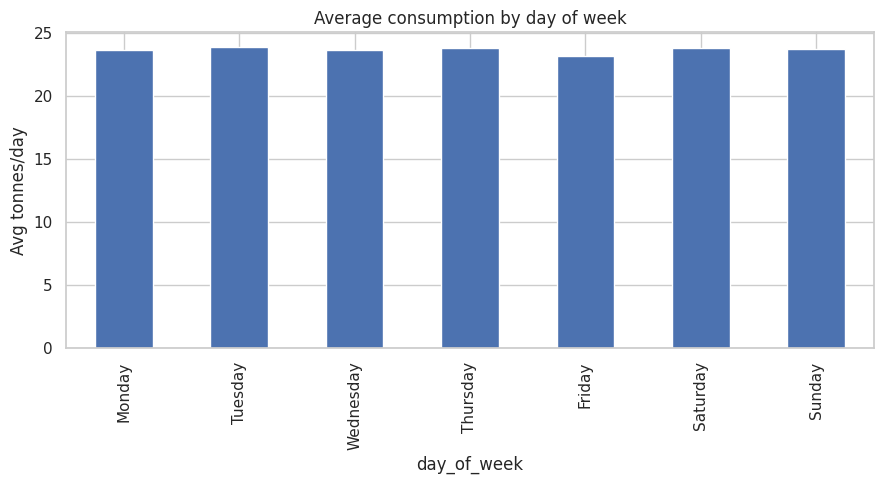

day_of_week
Monday       23.68
Tuesday      23.90
Wednesday    23.71
Thursday     23.89
Friday       23.23
Saturday     23.87
Sunday       23.77
Name: consumed_tonnes, dtype: float64


In [11]:
# Weekday/weekend pattern — matters for granularity choice: if pours are
# concentrated on weekdays, daily models need a day-of-week feature; if
# there's no effect, daily zeros are just noise and weekly aggregation
# (already used above) is the safer default.
df["day_of_week"] = df["date"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_summary = df.groupby("day_of_week")["consumed_tonnes"].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 5))
dow_summary.plot(kind="bar", ax=ax)
ax.set_title("Average consumption by day of week")
ax.set_ylabel("Avg tonnes/day")
plt.tight_layout()
plt.savefig("../data/processed/eda_04b_weekday.png", dpi=120)
plt.show()
print(dow_summary.round(2))

## 4b. Stationarity check (feeds Step 4 model selection)

The project's Step 4 baseline is SARIMAX, which needs to know whether the
series is stationary (constant mean/variance over time) to set the `d`
(differencing) parameter correctly. An Augmented Dickey-Fuller test on the
network-wide weekly series answers this now, rather than guessing at
model-build time.

In [12]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(network_weekly.dropna())
print(f"ADF statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.6f}")
print(f"Critical values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("\n-> Series is stationary (reject unit root null hypothesis at p<0.05).")
    print("   SARIMAX 'd' parameter can likely be set to 0 — differencing")
    print("   probably not needed. Confirm per-site during Step 4, since")
    print("   individual sites may behave differently from the network total.")
else:
    print("\n-> Series is non-stationary. Differencing (d=1) likely needed")
    print("   before SARIMAX fitting in Step 4.")

print(f"\nconsumed_tonnes skew: {df['consumed_tonnes'].skew():.3f} "
      f"({'roughly symmetric' if abs(df['consumed_tonnes'].skew()) < 0.5 else 'notable skew — consider log-transform for linear models'})")

ADF statistic: -13.101
p-value: 0.000000
Critical values: {'1%': np.float64(-3.472703119504854), '5%': np.float64(-2.880131672353732), '10%': np.float64(-2.5766826861130268)}

-> Series is stationary (reject unit root null hypothesis at p<0.05).
   SARIMAX 'd' parameter can likely be set to 0 — differencing
   probably not needed. Confirm per-site during Step 4, since
   individual sites may behave differently from the network total.

consumed_tonnes skew: 0.437 (roughly symmetric)


## 5. Weather correlation

Checks whether `rain_mm` and `avg_temp_c` show a meaningful relationship
with consumption — the brief calls out weather as a driver of pour
feasibility (concrete setting times), so this determines whether weather
belongs in the feature set as a real signal vs. noise.

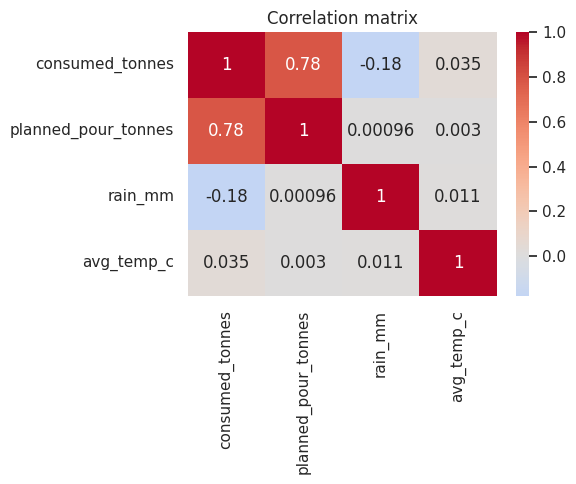

,consumed_tonnes,planned_pour_tonnes,rain_mm,avg_temp_c
consumed_tonnes,1.000000,0.781073,-0.180471,0.035107
planned_pour_tonnes,0.781073,1.000000,0.000962,0.002951
rain_mm,-0.180471,0.000962,1.000000,0.010923
avg_temp_c,0.035107,0.002951,0.010923,1.000000


In [13]:
corr_cols = ["consumed_tonnes", "planned_pour_tonnes", "rain_mm", "avg_temp_c"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.savefig("../data/processed/eda_06_weather_corr.png", dpi=120)
plt.show()
corr

In [14]:
# Heavy rain days vs. stockout/shortfall rate — a more targeted check
# than raw linear correlation, since the relationship may be threshold-based
# (pours simply don't happen past a rain threshold) rather than linear.
df["rain_band"] = pd.cut(df["rain_mm"], bins=[-0.1, 0, 5, 15, 100],
                          labels=["none", "light(0-5mm)", "moderate(5-15mm)", "heavy(15mm+)"])

rain_impact = df.groupby("rain_band").agg(
    avg_consumed=("consumed_tonnes", "mean"),
    avg_planned=("planned_pour_tonnes", "mean"),
    stockout_rate=("stockout_risk", "mean"),
    n=("date", "count"),
).round(3)
rain_impact

,avg_consumed,avg_planned,stockout_rate,n
rain_band,,,,
none,20.947,26.083,0.423,26
light(0-5mm),24.701,30.629,0.386,20760
moderate(5-15mm),24.856,30.852,0.382,10467
heavy(15mm+),3.945,30.645,0.639,1627


## 6. Planned pour vs. actual consumption

Quantifies how reliable `planned_pour_tonnes` is as a predictor of
`consumed_tonnes`. If schedule adherence is poor, the forecasting model
(Phase 3) needs to treat planned pours as a probabilistic input rather
than ground truth — this determines feature engineering, not just model
choice.

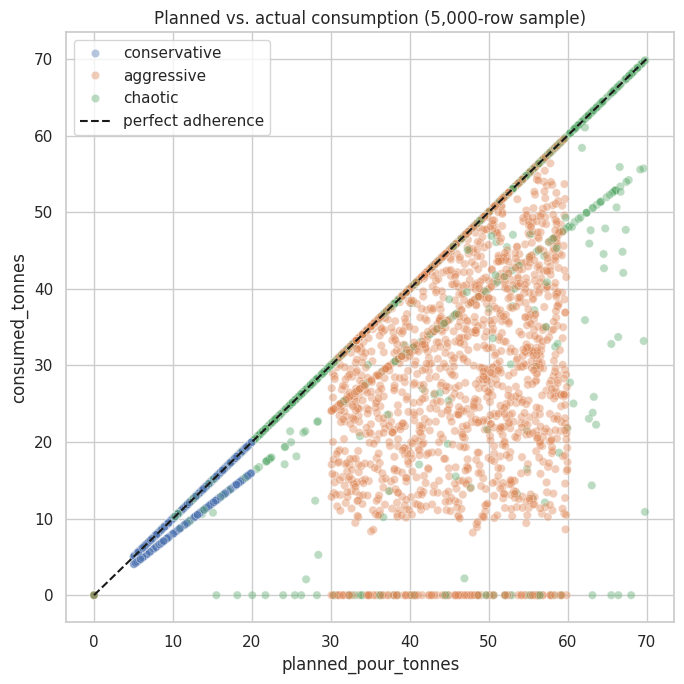

Overall planned-vs-actual correlation: 0.781

Correlation by behavior:
behavior
aggressive      0.485
chaotic         0.884
conservative    0.983
dtype: float64


In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
sample = df.sample(5000, random_state=42)
sns.scatterplot(data=sample, x="planned_pour_tonnes", y="consumed_tonnes",
                 hue="behavior", alpha=0.4, ax=ax)
lims = [0, df.planned_pour_tonnes.max()]
ax.plot(lims, lims, "k--", label="perfect adherence")
ax.set_title("Planned vs. actual consumption (5,000-row sample)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/eda_07_planned_vs_actual.png", dpi=120)
plt.show()

overall_corr = df["planned_pour_tonnes"].corr(df["consumed_tonnes"])
print(f"Overall planned-vs-actual correlation: {overall_corr:.3f}")
print()
print("Correlation by behavior:")
print(df.groupby("behavior").apply(lambda g: g.planned_pour_tonnes.corr(g.consumed_tonnes)).round(3))

## 7. Outlier detection

Flags statistical outliers per site (not globally — site scale varies a
lot, so a global threshold would just flag your biggest sites). Uses a
simple robust z-score on each site's own consumption distribution.

In [16]:
def flag_outliers(group, col="consumed_tonnes", threshold=3.5):
    median = group[col].median()
    mad = (group[col] - median).abs().median()
    if mad == 0:
        return pd.Series(False, index=group.index)
    modified_z = 0.6745 * (group[col] - median) / mad
    return modified_z.abs() > threshold

df["is_outlier"] = df.groupby("site_id", group_keys=False).apply(flag_outliers)

print(f"Outliers flagged: {df.is_outlier.sum()} / {len(df)} ({df.is_outlier.mean()*100:.2f}%)")
df[df.is_outlier].groupby("site_id").size().sort_values(ascending=False).head(10)

Outliers flagged: 0 / 32880 (0.00%)


Series([], dtype: int64)

## 8. Inventory dynamics — turnover & days-of-stock

Feeds directly into Phase 4 (inventory optimization / reorder points).
Days-of-stock = closing inventory ÷ trailing average daily consumption;
very low values flag sites running persistently close to stockout.

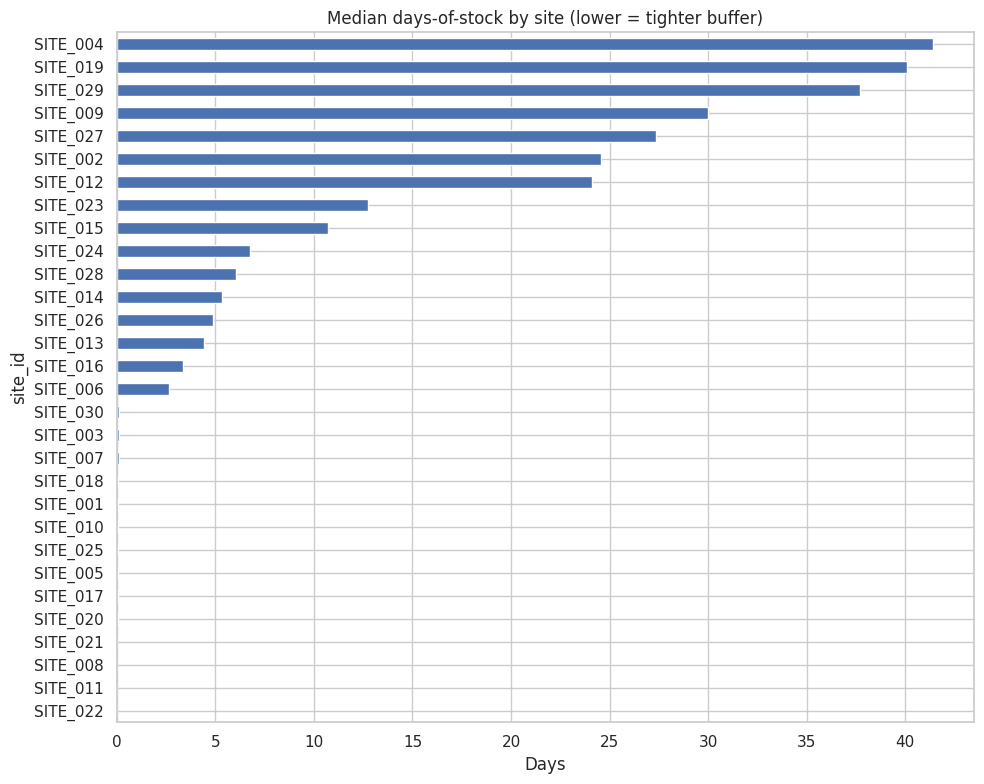

In [17]:
df_sorted = df.sort_values(["site_id", "date"])
df_sorted["consumed_7d_avg"] = (
    df_sorted.groupby("site_id")["consumed_tonnes"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)
df_sorted["days_of_stock"] = (
    df_sorted["closing_inventory_tonnes"] / df_sorted["consumed_7d_avg"].replace(0, np.nan)
)

days_of_stock_by_site = (
    df_sorted.groupby("site_id")["days_of_stock"]
    .median()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))
days_of_stock_by_site.plot(kind="barh", ax=ax)
ax.set_title("Median days-of-stock by site (lower = tighter buffer)")
ax.set_xlabel("Days")
plt.tight_layout()
plt.savefig("../data/processed/eda_08_days_of_stock.png", dpi=120)
plt.show()

## 9. Summary of findings (fill in after running)

- **Behavior segmentation matters**: `aggressive` sites show the highest
  stockout-risk rate; `conservative` sites show structural overstocking
  (see Phase 1 audit — capacity-capping applied). Confirms behavior should
  be a modeling feature and/or basis for per-segment strategy in Phase 3.
- **Seasonality**: _(inspect monthly/decomposition charts above and note
  whether a clear annual cycle exists — winter cement curing constraints
  are a common real-world pattern to look for)_.
- **Weather**: _(note correlation strength and whether the heavy-rain band
  shows a meaningfully different stockout rate — decides whether rain_mm
  earns a place as a regressor in SARIMAX/LightGBM, per Phase 3 plan)_.
- **Planned vs. actual adherence**: _(note the correlation value — if well
  below ~0.7-0.8, planned_pour_tonnes should be engineered as a soft
  signal, e.g. lagged/smoothed, not used directly as a forecast input)_.
- **Outliers**: _(note % flagged and whether concentrated in specific
  sites — worth a follow-up conversation with site managers before Phase
  3 if concentrated, as it may indicate real operational events rather
  than noise)_.
- **Inventory buffers**: _(note which sites show lowest days-of-stock —
  these are your highest-priority candidates for the Phase 6 pilot)_.
